## NewsAPI Client

The `NewsAPIClient` will handle interactions with the selected API (NewsAPI). This class will allow us to specify parameters like the number of articles, category, and country, and then fetch the articles.

In [41]:
import requests

class NewsAPIClient:
    def __init__(self, api_key, default_page_size=100, default_language='en'):
        self.api_key = api_key
        self.base_url = "https://newsapi.org/v2/"
        self.default_page_size = default_page_size
        self.default_language = default_language

    def fetch_articles(self, endpoint="top-headlines", query_params=None, page_size=None):
        # Use the provided page_size, or fall back to the client's default_page_size
        effective_page_size = page_size if page_size is not None else self.default_page_size

        params = {
            'apiKey': self.api_key,
            'pageSize': effective_page_size
        }

        # Add default language if not explicitly provided in query_params
        if query_params and 'language' not in query_params:
            params['language'] = self.default_language
        elif not query_params:
            params['language'] = self.default_language

        if query_params:
            params.update(query_params)

        try:
            full_url = f"{self.base_url}{endpoint}"
            response = requests.get(full_url, params=params)
            response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
            return response.json()
        except requests.exceptions.HTTPError as e:
            print(f"HTTP Error: {e.response.status_code} - {e.response.text}")
            return None
        except requests.exceptions.RequestException as e:
            print(f"Request Error: {e}")
            return None

    def display_articles(self, articles):
        if articles:
            print(f"Fetched {len(articles)} articles:\n")
            for i, article in enumerate(articles):
                print(f"Article {i+1}:")
                print(f"  Title: {article['title']}")
                print(f"  Source: {article['source']['name']}")
                print(f"  URL: {article['url']}\n")
        else:
            print("No articles to display.")


# Initialize the API client
NEWS_API_KEY = "6fbcc105837b458fb866d265fba9d767"
news_client = NewsAPIClient(NEWS_API_KEY)

print("NewsAPIClient initialized.")

NewsAPIClient initialized.


In [44]:
import pandas as pd

# Initialize preferences
news_category = None # We will iterate through predefined categories
display_article_count = 11 # Limit the articles displayed from the DataFrame to 10

# Define the list of categories and country to fetch
categories_to_fetch = ['business', 'entertainment', 'general', 'health', 'science', 'sports', 'technology']
country_to_fetch = None

all_articles = [] # List to store articles from all categories

print(f"Fetching articles for categories across all countries...")

for cat in categories_to_fetch:
    print(f"Fetching articles for category: {cat}")
    query_params = {
        'category': cat
    }

    # Fetch articles using the 'top-headlines' endpoint
    response_data = news_client.fetch_articles(endpoint="top-headlines", query_params=query_params)

    if response_data and response_data.get('status') == 'ok':
        fetched_articles = response_data.get('articles', [])
        # Add the category and country to each article before extending the main list
        for article in fetched_articles:
            article['fetched_category'] = cat
            article['fetched_country'] = country_to_fetch if country_to_fetch is not None else 'All Countries'
        all_articles.extend(fetched_articles)
    else:
        print(f"API call failed for category '{cat}' or returned no articles. Response data: {response_data}")

# Convert to DataFrame if articles were fetched
if all_articles:
    articles_df = pd.DataFrame(all_articles)

    # Extract source name
    articles_df['source_name'] = articles_df['source'].apply(lambda x: x['name'] if isinstance(x, dict) and 'name' in x else None)
    articles_df = articles_df.drop(columns=['source'])

    # Rename the temporarily added category and country columns to the final ones
    articles_df = articles_df.rename(columns={'fetched_category': 'category', 'fetched_country': 'country'})

    # Remove the 'country' and 'urlToImage' columns as requested
    columns_to_drop = ['country', 'urlToImage']
    articles_df = articles_df.drop(columns=[col for col in columns_to_drop if col in articles_df.columns])

    if not articles_df.empty:
        print(f"Successfully created DataFrame with {len(articles_df)} articles across all categories.")
        # Display only the head based on display_article_count
        display(articles_df.head(display_article_count))
    else:
        print("No articles to display.")
else:
    print("No articles fetched from the API to create a DataFrame.")
    articles_df = pd.DataFrame()

Fetching articles for categories across all countries...
Fetching articles for category: business
Fetching articles for category: entertainment
Fetching articles for category: general
Fetching articles for category: health
Fetching articles for category: science
Fetching articles for category: sports
Fetching articles for category: technology
Successfully created DataFrame with 329 articles across all categories.


,author,title,description,url,urlToImage,publishedAt,content,category,country,source_name
0,Amanda Silberling,"Who is John Ternus, the incoming Apple CEO? - ...","Starting on September 1, Ternus will lead one ...",https://techcrunch.com/2026/04/20/who-is-john-...,https://techcrunch.com/wp-content/uploads/2026...,2026-04-21T01:02:04Z,"After 15 years, Tim Cook will hand off the App...",business,All Countries,TechCrunch
1,Bob Cronin,"For Confirmation, Warsh Plans to Tout Fed Auto...",Prepared text suggests flexibility on other is...,https://www.newser.com/story/387663/for-confir...,https://img1-azrcdn.newser.com/image/1679558-1...,2026-04-20T22:55:00Z,"At the same time, the text has Warsh saying th...",business,All Countries,Newser
2,WSJ,"Anthropic, Amazon Tighten Bond in $5 Billion I...",None,https://www.wsj.com/tech/ai/anthropic-amazon-t...,None,2026-04-20T22:31:00Z,None,business,All Countries,The Wall Street Journal
3,"Frances Yue, Joseph Adinolfi, Jamie Chisholm, ...","Stock Market News April 20, 2026: Nasdaq snaps...",Follow all the latest U.S. market action for M...,https://www.marketwatch.com/livecoverage/s-p-5...,https://images.mktw.net/im-51746529/social,2026-04-20T21:40:00Z,None,business,All Countries,MarketWatch
4,Allison DeAngelis,Eli Lilly’s $3.25 billion acquisition of Kelon...,"Kelonia Therapeutics, a small biotech company,...",https://www.statnews.com/2026/04/20/kelonia-th...,https://www.statnews.com/wp-content/uploads/20...,2026-04-20T21:36:07Z,Eli Lilly is spending $3.25 billion to acquire...,business,All Countries,STAT
5,"Adam Clark, Al Root","Blue Origin Botched a Satellite Launch, but AS...",AST SpaceMobile stock is in focus after a sate...,https://www.barrons.com/articles/asts-stock-pr...,https://images.barrons.com/im-52387820/social,2026-04-20T20:24:00Z,AST SpaceMobilehas suffered a setback in its p...,business,All Countries,Barron's
6,Josh Funk,Two Southwest Airlines planes came dangerously...,Two Southwest Airlines planes had to take evas...,https://apnews.com/article/nashville-southwest...,https://dims.apnews.com/dims4/default/7daa7cf/...,2026-04-20T20:12:00Z,Two Southwest Airlines planes had to take evas...,business,All Countries,Associated Press
7,Sara Fischer,Judge orders Nexstar-Tegna to pause merger - A...,The ruling significantly dampens the consolida...,https://www.axios.com/2026/04/20/judge-orders-...,https://images.axios.com/K7kcJULV0YaOsfRuenyHT...,2026-04-20T19:15:30Z,"Zoom in: In a lengthy decision, District Judge...",business,All Countries,Axios
8,Bruce Gil,Rivian’s R2 Plant Was Struck by a Tornado Week...,The building where the company is producing it...,https://gizmodo.com/rivians-r2-plant-was-struc...,https://gizmodo.com/app/uploads/2026/04/240227...,2026-04-20T19:15:15Z,Rivian announced earlier this year that its ne...,business,All Countries,Gizmodo.com
9,Andrew J. Hawkins,Mercedes’ first all-electric C-Class is its sp...,Mercedes-Benz announced the first all-electric...,https://www.theverge.com/transportation/914951...,https://platform.theverge.com/wp-content/uploa...,2026-04-20T18:35:57Z,<ul><li></li><li></li><li></li></ul>\r\nThe ne...,business,All Countries,The Verge


### Distribution of Articles by Category

The pie chart below shows the proportion of articles belonging to each category.

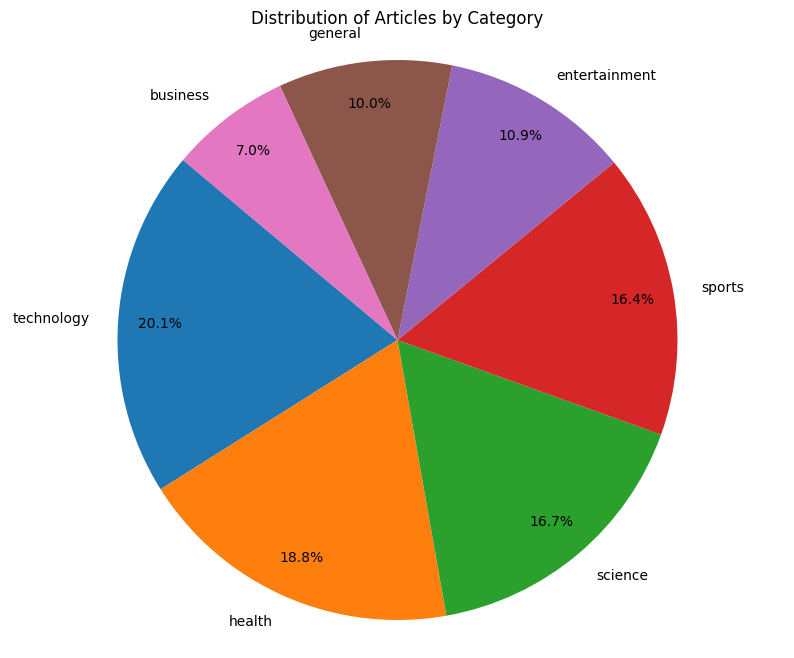

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

if not articles_df.empty:
    # Count articles per category
    category_counts = articles_df['category'].value_counts()

    # Create a pie chart
    plt.figure(figsize=(10, 8))
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
    plt.title('Distribution of Articles by Category')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()
else:
    print("No articles in the DataFrame to visualize.")

### Most Prevalent Source by Category

This section identifies the news source that appears most frequently within each news category, indicating the dominant publishers for specific topics.

In [46]:
if not articles_df.empty:
    # Group by category and then find the most frequent source_name in each group
    most_prevalent_sources = articles_df.groupby('category')['source_name'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')

    print("Most Prevalent Source by Category:")
    display(most_prevalent_sources.reset_index())
else:
    print("No articles in the DataFrame to analyze for most prevalent sources.")

Most Prevalent Source by Category:


,category,source_name
0,business,TechCrunch
1,entertainment,Variety
2,general,The Washington Post
3,health,SciTechDaily
4,science,The Daily Galaxy --Great Discoveries Channel
5,sports,NBCSports.com
6,technology,The Verge


### Source Ranking within a Single Category

The following bar chart displays the distribution of articles among different news sources for a **selected category**, ranked from the source with the most articles to the least. This helps in understanding which sources are most active or prominent within a particular topic.

/tmp/ipykernel_8458/1311367997.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='article_count', y='source_name', data=source_counts_in_category, palette='viridis')


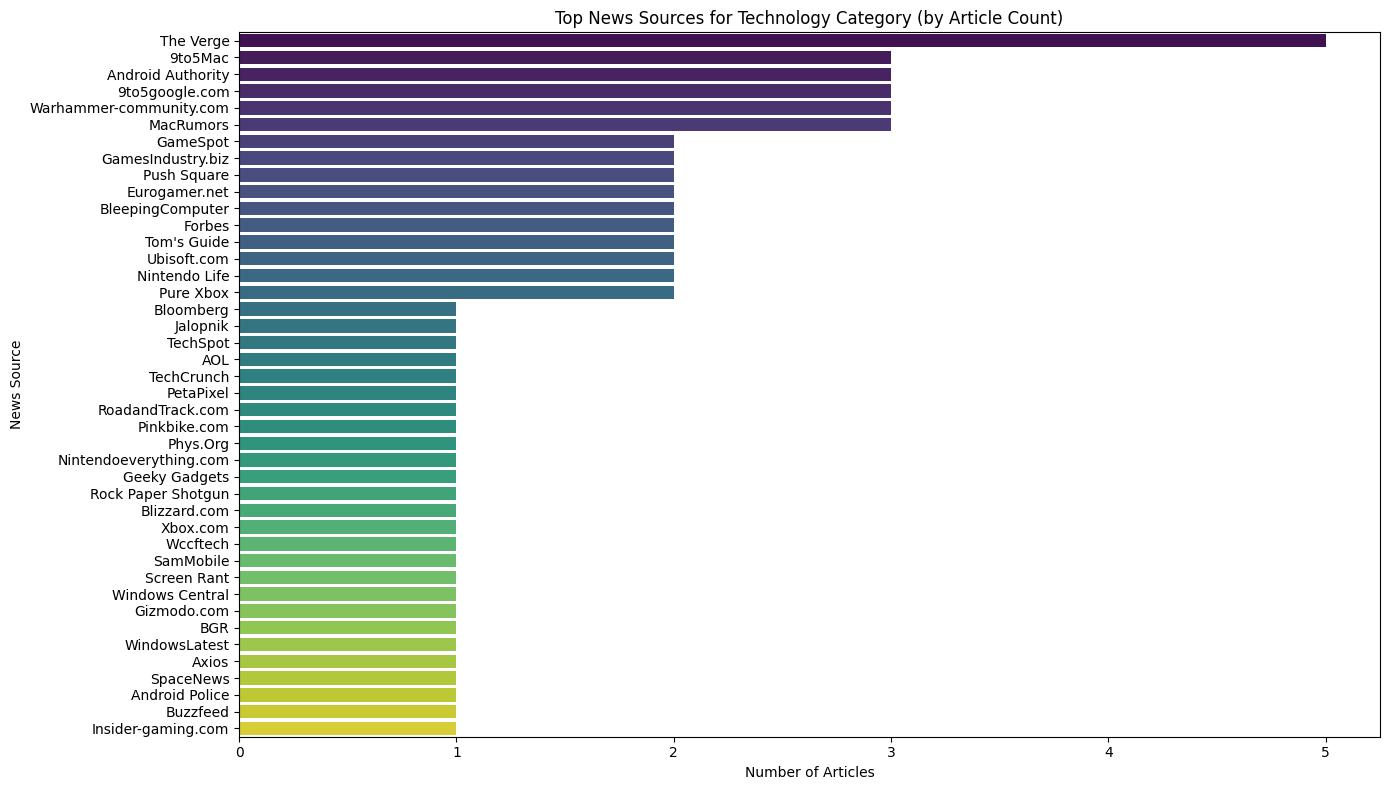

In [48]:
# Define the category you want to analyze
selected_category = 'technology' # You can change this to 'business', 'entertainment', etc.

if not articles_df.empty:
    # Filter the DataFrame for the selected category
    category_articles = articles_df[articles_df['category'] == selected_category]

    if not category_articles.empty:
        # Count the occurrences of each source_name in the selected category
        source_counts_in_category = category_articles['source_name'].value_counts().reset_index()
        source_counts_in_category.columns = ['source_name', 'article_count']

        # Create the bar plot
        plt.figure(figsize=(14, 8))
        sns.barplot(x='article_count', y='source_name', data=source_counts_in_category, palette='viridis')
        plt.title(f'Top News Sources for {selected_category.capitalize()} Category (by Article Count)')
        plt.xlabel('Number of Articles')
        plt.ylabel('News Source')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No articles found for the category: {selected_category}")
else:
    print("No articles in the DataFrame to analyze.")

## Web Scraping for Article Enrichment

The `WebScraping` class fetches the full content of an article from its URL and extracts various details to enrich the article content with its full version.

The `WebScraping` class will include methods to:
-   Fetch the HTML content of a given URL.
-   Parse the HTML using `BeautifulSoup`.
-   Attempt to extract the full article text.

### Other Potential Data to Extract via Web Scraping:
Beyond the full article text, you might want to extract:

1.  **Author Information:** Sometimes the API only provides a general author, but the article page might have a more detailed author profile or byline.
2.  **Publication Date/Time:** While the API provides `publishedAt`, scraping can sometimes yield more precise or alternative date formats.
3.  **Tags/Keywords:** Many news sites include tags or keywords related to the article, which can be useful for more granular categorization or topic modeling.
4.  **Related Articles:** Links to other articles on the same site can help build a network of related content.

The `extract_full_text` method provided below is a generic attempt to find common article content sections. **Please note:** Web scraping can be fragile; different websites use different HTML structures, so you might need to customize the scraping logic (e.g., specific CSS selectors or HTML tags) for the websites you frequently encounter to get optimal results.

In [55]:
import requests
from bs4 import BeautifulSoup
import re

class WebScraping:
    def __init__(self, timeout=10):
        self.timeout = timeout

    def fetch_and_parse(self, url):
        try:
            headers = {'User-Agent': 'Mozilla/5.0'}
            response = requests.get(url, headers=headers, timeout=self.timeout)
            response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
            soup = BeautifulSoup(response.text, 'html.parser')
            return soup
        except requests.exceptions.RequestException as e:
            print(f"Error fetching {url}: {e}")
            return None

    def extract_full_text(self, soup):
        if not soup:
            return None

        # Common selectors for main article content
        # This list can be expanded and ordered by priority
        selectors = [
            'article',
            'div[itemprop="articleBody"]',
            'div.entry-content',
            'div.article-content',
            'div.story-body',
            'div.post-content',
            'main',
            'div.content-body'
        ]

        for selector in selectors:
            content_div = soup.find(selector)
            if content_div:
                # Extract text from paragraphs within the content div
                paragraphs = content_div.find_all('p')
                article_text = '\n\n'.join([p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True)])
                if article_text:
                    return article_text

        # Fallback: if no specific article content div is found, try to get all visible text
        return soup.get_text(separator=' ', strip=True)

    def _normalize_text(self, text):
        if not text:
            return ""
        text = text.lower()
        # Remove punctuation but keep spaces, then remove extra spaces
        text = re.sub(r'[^a-z0-9\s]', '', text).strip()
        text = re.sub(r'\s+', ' ', text)
        return text

    def cross_check_scraped_text(self, full_text, api_description, api_content):
        if not full_text:
            return False, "No full text extracted for cross-check."

        # Prioritize description for comparison, fall back to content if description is missing
        api_text_to_compare = api_description if api_description else api_content

        if not api_text_to_compare:
            # If no description or content from API, we can't cross-check effectively, assume success for this criterion
            return True, "No API description/content for cross-check."

        normalized_full_text = self._normalize_text(full_text)
        normalized_api_text = self._normalize_text(api_text_to_compare)

        # 1. Check for significant length increase (full text should be longer than API summary)
        # If full_text is not longer, it's likely not the "full" article.
        # Allow for some margin (e.g., 10% longer) to account for slight variations.
        if len(normalized_full_text) < len(normalized_api_text) * 1.1:
            return False, f"Scraped text ({len(normalized_full_text)} chars) is not substantially longer than API text ({len(normalized_api_text)} chars)."

        # 2. Check if the API description (or content) is substantially present in the full_text
        # Use a token-based approach for more flexibility than strict substring match.
        api_words = set(word for word in normalized_api_text.split() if len(word) > 2) # Ignore very short words
        full_text_words = set(word for word in normalized_full_text.split() if len(word) > 2)

        if not api_words: # If API text was empty after normalization or only short words
            return True, "No significant API words to cross-check against."

        matching_words_count = len(api_words.intersection(full_text_words))
        required_match_ratio = 0.7 # e.g., 70% of API description words must be in full_text

        if (matching_words_count / len(api_words)) < required_match_ratio:
            return False, f"Only {matching_words_count}/{len(api_words)} ({matching_words_count / len(api_words):.1%}) of API words found in scraped text."

        return True, "Cross-check successful."

print("WebScraping class defined with cross-check validation.")

WebScraping class defined with cross-check validation.


### Demonstration of WebScraping Class

Below is an example of how to use the `WebScraping` class to extract the full text from one of the articles in your `articles_df`. We'll pick the first article as a demonstration.

In [56]:
if not articles_df.empty:
    # Initialize the web scraper
    scraper = WebScraping()

    # Select a sample article URL
    sample_article = articles_df.iloc[0]
    article_url = sample_article['url']
    article_title = sample_article['title']

    print(f"Attempting to scrape full text from: {article_title}\nURL: {article_url}")

    # Fetch and parse the article page
    soup = scraper.fetch_and_parse(article_url)

    if soup:
        # Extract the full text
        full_text = scraper.extract_full_text(soup)

        if full_text:
            print("\n--- Extracted Full Text (first 500 characters) ---")
            print(full_text[:500] + ('...' if len(full_text) > 500 else ''))
            print("\n--- End of Snippet ---")
        else:
            print("Could not extract full text from the article.")
    else:
        print("Failed to fetch or parse the article page.")
else:
    print("The articles_df is empty. Cannot demonstrate web scraping.")

Attempting to scrape full text from: Who is John Ternus, the incoming Apple CEO? - TechCrunch
URL: https://techcrunch.com/2026/04/20/who-is-john-ternus-the-incoming-apple-ceo/

--- Extracted Full Text (first 500 characters) ---
After 15 years, Tim Cook willhand off the Apple CEO roleto John Ternus, the company’s senior vice president of hardware engineering. Starting on September 1, Ternus will lead one of the world’s most valuable companies, but if you’re not a dedicated Apple enthusiast, you’ve probably never heard of this man, who has largely remained out of the spotlight until now.

Ternus has worked at Apple for nearly half of his life — now 51 years old, he has been with the company for 25 years.

He joined Apple...

--- End of Snippet ---


### Web Scraping Demonstration: One Article Per Unique Source

This section demonstrates the `WebScraping` class by attempting to extract full text from one article for each unique news source present in the `articles_df`. This provides a broader test of the scraping functionality across different website structures.

In [57]:
if not articles_df.empty:
    scraper = WebScraping()
    unique_sources = articles_df['source_name'].unique()

    print(f"Attempting to scrape one article from each of {len(unique_sources)} unique sources with cross-checking...")

    scraped_results = []

    for source_name in unique_sources:
        # Find the first article for this source
        article_from_source = articles_df[articles_df['source_name'] == source_name].iloc[0]
        article_url = article_from_source['url']
        article_title = article_from_source['title']
        api_description = article_from_source.get('description')
        api_content = article_from_source.get('content')

        print(f"\n--- Processing Source: {source_name} ---")
        print(f"  Article: {article_title}")
        print(f"  URL: {article_url}")

        soup = scraper.fetch_and_parse(article_url)
        full_text = None
        status = 'Failed'
        validation_reason = ''

        if soup:
            extracted_text = scraper.extract_full_text(soup)
            if extracted_text:
                # Perform cross-check validation
                is_valid_scrape, validation_reason = scraper.cross_check_scraped_text(
                    extracted_text,
                    api_description,
                    api_content
                )
                if is_valid_scrape:
                    full_text = extracted_text # Assign if valid
                    status = 'Success'
                else:
                    print(f"  Scrape validation failed: {validation_reason}")
            else:
                validation_reason = "Could not extract any text from the article page."
        else:
            validation_reason = "Failed to fetch or parse the article page."

        if full_text:
            print("  Extracted and Validated Full Text (first 200 characters):")
            print(full_text[:200] + ('...' if len(full_text) > 200 else ''))
            scraped_results.append({'source': source_name, 'article_title': article_title, 'status': status})
        else:
            print(f"  Could not extract or validate full text from the article. Reason: {validation_reason}")
            scraped_results.append({'source': source_name, 'article_title': article_title, 'status': status})

    print("\n--- Summary of Scraping by Unique Source ---")
    results_df = pd.DataFrame(scraped_results)
    display(results_df['status'].value_counts())
    print("\n--- End of Unique Source Scraping Demonstration ---")

else:
    print("The articles_df is empty. Cannot demonstrate web scraping on unique sources.")

Attempting to scrape one article from each of 180 unique sources with cross-checking...

--- Processing Source: TechCrunch ---
  Article: Who is John Ternus, the incoming Apple CEO? - TechCrunch
  URL: https://techcrunch.com/2026/04/20/who-is-john-ternus-the-incoming-apple-ceo/
  Extracted and Validated Full Text (first 200 characters):
After 15 years, Tim Cook willhand off the Apple CEO roleto John Ternus, the company’s senior vice president of hardware engineering. Starting on September 1, Ternus will lead one of the world’s most v...

--- Processing Source: Newser ---
  Article: For Confirmation, Warsh Plans to Tout Fed Autonomy on Rates - Newser
  URL: https://www.newser.com/story/387663/for-confirmation-warsh-plans-to-tout-fed-autonomy-on-rates.html
  Scrape validation failed: Only 4/6 (66.7%) of API words found in scraped text.
  Could not extract or validate full text from the article. Reason: Only 4/6 (66.7%) of API words found in scraped text.

--- Processing Source: The Wall 

,count
status,
Success,111
Failed,69



--- End of Unique Source Scraping Demonstration ---


### Indicating Scraping Enrichability in the DataFrame

Based on the web scraping demonstration by unique source, a new column will be added to the `articles_df`. This column, `scraping_available`, will indicate whether articles from a particular source were successfully scraped (True) or not (False).

In [54]:
if not articles_df.empty and not results_df.empty:
    # Create a mapping from source name to scraping success status
    scraping_success_map = results_df.set_index('source')['status'].apply(lambda x: x == 'Success').to_dict()

    # Apply this map to the articles_df to create the new column
    articles_df['scraping_available'] = articles_df['source_name'].map(scraping_success_map)

    # Handle sources that were not part of the unique source scraping test (if any)
    # These would have NaN after mapping, so we can fill them with False
    articles_df['scraping_available'].fillna(False, inplace=True)

    print("New column 'scraping_available' added to articles_df and 'The Verge' reclassified.")
    display(articles_df[['title', 'source_name', 'scraping_available']].head(10))
else:
    print("articles_df or results_df is empty. Cannot add enrichability column.")

New column 'scraping_available' added to articles_df.


/tmp/ipykernel_8458/4186590956.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  articles_df['scraping_available'].fillna(False, inplace=True)


,title,source_name,scraping_available
0,"Who is John Ternus, the incoming Apple CEO? - ...",TechCrunch,True
1,"For Confirmation, Warsh Plans to Tout Fed Auto...",Newser,True
2,"Anthropic, Amazon Tighten Bond in $5 Billion I...",The Wall Street Journal,False
3,"Stock Market News April 20, 2026: Nasdaq snaps...",MarketWatch,False
4,Eli Lilly’s $3.25 billion acquisition of Kelon...,STAT,True
5,"Blue Origin Botched a Satellite Launch, but AS...",Barron's,False
6,Two Southwest Airlines planes came dangerously...,Associated Press,True
7,Judge orders Nexstar-Tegna to pause merger - A...,Axios,False
8,Rivian’s R2 Plant Was Struck by a Tornado Week...,Gizmodo.com,True
9,Mercedes’ first all-electric C-Class is its sp...,The Verge,True


### Scraping Full Content for Available Articles

Now, we will iterate through the entire `articles_df`. For each article where `scraping_available` is `True`, we will attempt to scrape its full content from the provided URL. The extracted and validated full text will be stored in a new column called `content_scraping`.

In [58]:
import numpy as np
from tqdm.notebook import tqdm

tqdm.pandas()

if not articles_df.empty:
    scraper = WebScraping()

    # Define a function to apply row-wise for scraping and validation
    def get_scraped_content(row):
        if not row['scraping_available']:
            return np.nan # Use NaN for sources where scraping is not available

        article_url = row['url']
        api_description = row.get('description')
        api_content = row.get('content')

        # Fetch and parse the article page
        soup = scraper.fetch_and_parse(article_url)
        if not soup:
            # print(f"  Failed to fetch or parse {article_url}") # Uncomment for detailed logging
            return np.nan

        # Extract the full text
        extracted_text = scraper.extract_full_text(soup)
        if not extracted_text:
            # print(f"  Could not extract full text from {article_url}") # Uncomment for detailed logging
            return np.nan

        # Perform cross-check validation
        is_valid_scrape, validation_reason = scraper.cross_check_scraped_text(
            extracted_text,
            api_description,
            api_content
        )

        if is_valid_scrape:
            return extracted_text
        else:
            # print(f"  Validation failed for {article_url}: {validation_reason}") # Uncomment for detailed logging
            return np.nan

    print("Starting full content scraping for articles with available sources...")
    # Apply the function to create the new 'content_scraping' column
    articles_df['content_scraping'] = articles_df.progress_apply(get_scraped_content, axis=1)

    # Display the head of the DataFrame with the new column, focusing on scraped content if available
    print("\nFull content scraping complete. Displaying first 10 rows with new 'content_scraping' column:")
    display(articles_df[['title', 'source_name', 'scraping_available', 'content_scraping']].head(10))

    # Show summary of scraped vs non-scraped articles
    scraped_count = articles_df['content_scraping'].notna().sum()
    total_articles = len(articles_df)
    print(f"\nTotal articles: {total_articles}")
    print(f"Articles with successfully scraped content: {scraped_count}")
    print(f"Articles where scraping was attempted but failed/not available: {total_articles - scraped_count}")

else:
    print("The articles_df is empty. Cannot perform full content scraping.")

Starting full content scraping for articles with available sources...


  0%|          | 0/329 [00:00<?, ?it/s]

Error fetching http://spacenews.com/in-the-wake-of-artemis-2-america-needs-to-consider-the-why-of-its-government-space-program/: 429 Client Error: Too Many Requests for url: https://spacenews.com/in-the-wake-of-artemis-2-america-needs-to-consider-the-why-of-its-government-space-program/

Full content scraping complete. Displaying first 10 rows with new 'content_scraping' column:


,title,source_name,scraping_available,content_scraping
0,"Who is John Ternus, the incoming Apple CEO? - ...",TechCrunch,True,"After 15 years, Tim Cook willhand off the Appl..."
1,"For Confirmation, Warsh Plans to Tout Fed Auto...",Newser,True,NaN
2,"Anthropic, Amazon Tighten Bond in $5 Billion I...",The Wall Street Journal,False,NaN
3,"Stock Market News April 20, 2026: Nasdaq snaps...",MarketWatch,False,NaN
4,Eli Lilly’s $3.25 billion acquisition of Kelon...,STAT,True,NaN
5,"Blue Origin Botched a Satellite Launch, but AS...",Barron's,False,NaN
6,Two Southwest Airlines planes came dangerously...,Associated Press,True,Southwest Airlines grounds crew refuel an airc...
7,Judge orders Nexstar-Tegna to pause merger - A...,Axios,False,NaN
8,Rivian’s R2 Plant Was Struck by a Tornado Week...,Gizmodo.com,True,Rivian announced earlier this year that its ne...
9,Mercedes’ first all-electric C-Class is its sp...,The Verge,True,Posts from this topic will be added to your da...



Total articles: 329
Articles with successfully scraped content: 210
Articles where scraping was attempted but failed/not available: 119


## Keyword Extraction and Analysis

The `FrequentKeywords` class will extract the most relevant keywords from article content. It handles preprocessing, stopwords removal, and lemmatization to provide a cleaner and more accurate representation of an article's core topics. The class will prioritize scraped content (`content_scraping`) if available, otherwise it will use the `content` provided by the API.

In [62]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter
import string

# Download necessary NLTK data (only run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    # This specific resource seems to be required by word_tokenize internally
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

class FrequentKeywords:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        # Add common news-related stopwords or non-informative words
        self.stop_words.update(['said', 'say', 'says', 'one', 'would', 'could', 'also', 'told', 'us', 'new', 'get', 'like', 'news', 'story', 'article', 'full', 'text', 'first', 'chars'])
        self.lemmatizer = WordNetLemmatizer()

    def _preprocess_text(self, text):
        if not text: # Handle empty or None text
            return []
        # Convert to lowercase
        text = text.lower()
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Tokenize words
        tokens = word_tokenize(text)
        return tokens

    def _remove_stopwords(self, tokens):
        return [word for word in tokens if word not in self.stop_words]

    def _lemmatize_tokens(self, tokens):
        return [self.lemmatizer.lemmatize(word) for word in tokens]

    def extract_keywords(self, article_content, top_n=10):
        # Preprocess, remove stopwords, and lemmatize
        tokens = self._preprocess_text(article_content)
        filtered_tokens = self._remove_stopwords(tokens)
        lemmatized_tokens = self._lemmatize_tokens(filtered_tokens)

        # Remove single-character tokens after lemmatization/filtering
        lemmatized_tokens = [word for word in lemmatized_tokens if len(word) > 1]

        # Count word frequencies
        word_counts = Counter(lemmatized_tokens)
        return word_counts.most_common(top_n)

print("FrequentKeywords class and NLTK downloads initialized.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


FrequentKeywords class and NLTK downloads initialized.


### Demonstration of Keyword Extraction

Let's demonstrate the `FrequentKeywords` class by extracting the top keywords from a sample article. We'll prioritize the `content_scraping` if it's available, otherwise, we'll fall back to the API's `content`.

In [63]:
if not articles_df.empty:
    keyword_extractor = FrequentKeywords()

    # Select a sample article (e.g., the first one with scraped content)
    sample_article = articles_df[articles_df['content_scraping'].notna()].iloc[0]

    article_title = sample_article['title']
    content_to_analyze = sample_article['content_scraping'] if pd.notna(sample_article['content_scraping']) else sample_article['content']

    if content_to_analyze:
        print(f"Analyzing keywords for article: '{article_title}'")
        top_keywords = keyword_extractor.extract_keywords(content_to_analyze, top_n=15)
        print("\nTop 15 Keywords:")
        for keyword, count in top_keywords:
            print(f"- {keyword}: {count}")
    else:
        print(f"No content available for analysis for article: '{article_title}'")
else:
    print("The articles_df is empty. Cannot demonstrate keyword extraction.")

Analyzing keywords for article: 'Who is John Ternus, the incoming Apple CEO? - TechCrunch'

Top 15 Keywords:
- apple: 22
- ternus: 21
- year: 7
- company: 6
- hardware: 6
- product: 5
- cook: 4
- ceo: 4
- senior: 4
- engineering: 4
- lead: 4
- launch: 4
- building: 4
- never: 3
- design: 3


### Most Prevalent Keywords within a Category

This section demonstrates how to find the most prevalent keywords across all articles within a *selected category*. This helps in identifying the core topics and recurring themes for a given subject area.

In [64]:
if not articles_df.empty:
    keyword_extractor = FrequentKeywords()

    # Define the category to analyze
    category_to_analyze = 'technology' # You can change this to any category from your DataFrame

    print(f"Analyzing most prevalent keywords for the '{category_to_analyze.capitalize()}' category...")

    # Filter articles for the chosen category
    category_articles = articles_df[articles_df['category'] == category_to_analyze]

    if not category_articles.empty:
        all_category_keywords = Counter()

        # Use tqdm for progress tracking
        for index, row in tqdm(category_articles.iterrows(), total=category_articles.shape[0], desc=f"Processing {category_to_analyze} articles"):
            content_to_analyze = row['content_scraping'] if pd.notna(row['content_scraping']) else row['content']

            if content_to_analyze:
                keywords = keyword_extractor.extract_keywords(content_to_analyze, top_n=None) # Extract all keywords
                all_category_keywords.update(dict(keywords))

        if all_category_keywords:
            print(f"\nTop 20 Most Prevalent Keywords in '{category_to_analyze.capitalize()}' Category:")
            for keyword, count in all_category_keywords.most_common(20):
                print(f"- {keyword}: {count}")
        else:
            print(f"No keywords could be extracted for the '{category_to_analyze}' category.")
    else:
        print(f"No articles found for the category: {category_to_analyze}")
else:
    print("The articles_df is empty. Cannot perform keyword analysis by category.")

Analyzing most prevalent keywords for the 'Technology' category...


Processing technology articles:   0%|          | 0/66 [00:00<?, ?it/s]


Top 20 Most Prevalent Keywords in 'Technology' Category:
- ai: 124
- galaxy: 86
- apple: 85
- see: 85
- samsung: 83
- daily: 77
- post: 76
- feature: 71
- email: 65
- added: 64
- digest: 63
- feed: 62
- game: 59
- homepage: 58
- make: 58
- device: 55
- 2026: 51
- user: 49
- use: 49
- iphone: 48
